# Cross-tool Coherence Analysis
## Unified SEO Intelligence across GSC, GA4, Ahrefs, and Clarity

This notebook synthesizes findings from all three previous milestones to test 
whether Google Search Console, Google Analytics 4, Ahrefs, and Microsoft Clarity 
tell a consistent story about content performance. This will also analyze where they meaningfully disagree.

**Pages in scope:** Top pages appearing across at least two tools  
**Objective:** Build a unified coherence score and final opportunity ranking

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os

os.makedirs('../output-coherence/chart', exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## 1. Loading data from all three milestones

Reloading the cleaned GSC + GA4 page metrics, Ahrefs page data, 
and Clarity top pages to build a unified comparison dataset.

### Milestone 1 — GSC & GA4 pages

In [3]:
# Milestone 1 — GSC + GA4
gsc_pages = pd.read_csv('../../data/gsc_pages.csv')
ga4 = pd.read_csv('../../data/ga4_landing_page.csv', skiprows=9)

gsc_pages.columns = gsc_pages.columns.str.strip()
ga4.columns = ga4.columns.str.strip()
gsc_pages = gsc_pages.rename(columns={'Top pages': 'Page'})
ga4 = ga4.rename(columns={'Landing page': 'Page'})

def clean_url(col):
    return (
        col.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r'https?://[^/]+', '', regex=True)
        .str.rstrip('/')
    )

gsc_pages['Page'] = clean_url(gsc_pages['Page'])
ga4['Page'] = clean_url(ga4['Page'])
ga4 = ga4[ga4['Page'].str.startswith('/')]

page_metrics = pd.merge(gsc_pages, ga4, on='Page', how='inner')
page_metrics = page_metrics.rename(columns={
    'Clicks': 'gsc_clicks',
    'Impressions': 'gsc_impressions',
    'CTR': 'gsc_ctr',
    'Position': 'gsc_position',
    'Sessions': 'ga_sessions',
    'Average engagement time per session': 'ga_engagement_time'
})
page_metrics['gsc_ctr'] = page_metrics['gsc_ctr'].str.replace('%', '', regex=False).astype(float) / 100
page_metrics['engagement_efficiency'] = page_metrics['ga_engagement_time'] / page_metrics['ga_sessions']

print(f"Milestone 1 — page_metrics: {page_metrics.shape[0]} pages")
print(page_metrics[['Page', 'gsc_impressions', 'ga_sessions', 'engagement_efficiency']].head())

Milestone 1 — page_metrics: 74 pages
                                         Page  gsc_impressions  ga_sessions  \
0                      /blogs/paypal-in-nepal            61503          257   
1                                       /zoom             4076           65   
2  /blogs/zoom-not-working-troubleshoot-guide            26600          140   
3  /blogs/aws-in-2026-latest-services-updates            80547          592   
4                  /cloud-consulting-in-nepal             1431           53   

   engagement_efficiency  
0               0.115278  
1               1.138935  
2               0.262857  
3               0.029900  
4               0.224635  


### Milestone 2 — Ahrefs pages

In [5]:
ahrefs_pages = pd.read_csv('../../data/ahrefs_top_pages.csv')

def clean_ahrefs(df):
    df.columns = df.columns.str.replace('"', '', regex=False).str.strip()
    for col in df.select_dtypes(include='str').columns:
        df[col] = df[col].str.replace('"', '', regex=False).str.strip()
    return df

ahrefs_pages = clean_ahrefs(ahrefs_pages)
ahrefs_pages['Page'] = clean_url(ahrefs_pages['URL'])

numeric_cols = ['UR', 'Traffic', 'Traffic value', 'Referring domains', 'Keywords']
for col in numeric_cols:
    ahrefs_pages[col] = pd.to_numeric(ahrefs_pages[col], errors='coerce')

ahrefs_pages = ahrefs_pages.rename(columns={'Traffic': 'ahrefs_traffic'})

print(f"Milestone 2 — ahrefs_pages: {ahrefs_pages.shape[0]} pages")
print(ahrefs_pages[['Page', 'ahrefs_traffic', 'Referring domains', 'Keywords']])

Milestone 2 — ahrefs_pages: 8 pages
                                           Page  ahrefs_traffic  \
0    /blogs/zoom-not-working-troubleshoot-guide              91   
1                        /blogs/paypal-in-nepal              39   
2     /blogs/zoom-camera-issues-easy-detect-fix              35   
3  /blogs/fix-zoom-audio-mic-speaker-issue-fast              11   
4  /blogs/what-is-aws-guide-amazon-web-services               1   
5   /blogs/simple-comparison-of-zoom-vs-discord               1   
6         /blogs/complete-guide-to-aws-database               0   
7      /blogs/free-zoom-vs-paid-which-is-better               0   

   Referring domains  Keywords  
0                  0        26  
1                  1         8  
2                  0         9  
3                  0         2  
4                  1         1  
5                  0         2  
6                  0         2  
7                  0         2  


### Milestone 3 — Clarity pages

In [6]:
clarity_raw = pd.read_csv('../../data/clarity_analysis_raw.csv', header=None)

section_indices = clarity_raw[
    clarity_raw[0].astype(str).str.contains('Metric', na=False)
].index.tolist()

sections = {}
for i, start_idx in enumerate(section_indices):
    section_name = clarity_raw.iloc[start_idx, 1]
    end_idx = section_indices[i + 1] if i < len(section_indices) - 1 else len(clarity_raw)
    section_df = clarity_raw.iloc[start_idx + 1:end_idx].copy()
    section_df = section_df.dropna(how='all')
    sections[section_name] = section_df.reset_index(drop=True)

clarity_pages = sections['Top pages'].copy()
clarity_pages = clarity_pages[[1, 2]].dropna()
clarity_pages.columns = ['page', 'clarity_sessions']
clarity_pages['Page'] = clean_url(clarity_pages['page'])
clarity_pages['clarity_sessions'] = pd.to_numeric(clarity_pages['clarity_sessions'], errors='coerce')
clarity_pages = clarity_pages.dropna(subset=['clarity_sessions'])

print(f"Milestone 3 — clarity_pages: {clarity_pages.shape[0]} pages")
print(clarity_pages[['Page', 'clarity_sessions']])

Milestone 3 — clarity_pages: 12 pages
                                           Page  clarity_sessions
0   /blogs/simple-comparison-of-zoom-vs-discord               473
1    /blogs/aws-in-2026-latest-services-updates               370
2                                                             202
3   /blogs/amazon-bedrock-aws-ai-platform-guide               168
4                        /blogs/paypal-in-nepal               133
5    /blogs/zoom-not-working-troubleshoot-guide               119
6                                   /contact-us                65
7         /blogs/complete-guide-to-aws-database                47
8     /blogs/zoom-camera-issues-easy-detect-fix                47
9                                       /career                44
10     /blogs/free-zoom-vs-paid-which-is-better                40
11                                    /services                40


## 2. Building the unified page-level dataset

Joining all three milestones on the Page key. Using outer join to 
preserve pages that appear in any tool, even if missing from others.

In [7]:
unified = page_metrics[['Page', 'gsc_impressions', 'gsc_clicks', 'ga_sessions', 'engagement_efficiency']].merge(
    ahrefs_pages[['Page', 'ahrefs_traffic', 'Referring domains', 'Keywords']],
    on='Page', how='outer'
).merge(
    clarity_pages[['Page', 'clarity_sessions']],
    on='Page', how='outer'
)

# Keep only pages with data from at least 2 tools
unified['tool_count'] = (
    unified[['gsc_impressions', 'ahrefs_traffic', 'clarity_sessions']].notna().sum(axis=1)
)

coherence_set = unified[unified['tool_count'] >= 2].copy()

print(f"Pages with data from 2+ tools: {coherence_set.shape[0]}")
print(coherence_set[['Page', 'gsc_impressions', 'ga_sessions', 'ahrefs_traffic', 'clarity_sessions', 'tool_count']].to_string())

Pages with data from 2+ tools: 14
                                            Page  gsc_impressions  ga_sessions  ahrefs_traffic  clarity_sessions  tool_count
6    /blogs/amazon-bedrock-aws-ai-platform-guide          49523.0        232.0             NaN             168.0           2
7     /blogs/aws-in-2026-latest-services-updates          80547.0        592.0             NaN             370.0           2
9          /blogs/complete-guide-to-aws-database          10061.0         78.0             0.0              47.0           3
10  /blogs/fix-zoom-audio-mic-speaker-issue-fast           1383.0          7.0            11.0               NaN           2
11      /blogs/free-zoom-vs-paid-which-is-better          12429.0         52.0             0.0              40.0           3
13                        /blogs/paypal-in-nepal          61503.0        257.0            39.0             133.0           3
14   /blogs/simple-comparison-of-zoom-vs-discord           3203.0        338.0             

## 3. Deduplication
Removing duplicate page entries caused by URL variants.

In [8]:
# Check the duplicate
print(coherence_set[coherence_set['Page'] == '/services'])

# Keep the row with higher impressions (likely the canonical URL)
coherence_set = coherence_set.sort_values('gsc_impressions', ascending=False).drop_duplicates(subset='Page', keep='first')

print(f"\nPages after dedup: {coherence_set.shape[0]}")

         Page  gsc_impressions  gsc_clicks  ga_sessions  \
60  /services            972.0         7.0         27.0   
61  /services            131.0         0.0         27.0   

    engagement_efficiency  ahrefs_traffic  Referring domains  Keywords  \
60               3.893004             NaN                NaN       NaN   
61               3.893004             NaN                NaN       NaN   

    clarity_sessions  tool_count  
60              40.0           2  
61              40.0           2  

Pages after dedup: 13


## 4. Building the coherence score

For each page, we rank its performance within each tool (percentile rank), 
then measure the spread between tools. Low spread = high coherence 
(tools agree). High spread = low coherence (tools disagree).

In [9]:
metrics_to_rank = ['gsc_impressions', 'ga_sessions', 'ahrefs_traffic', 'clarity_sessions']

for col in metrics_to_rank:
    coherence_set[f'{col}_rank'] = coherence_set[col].rank(pct=True)

rank_cols = [f'{col}_rank' for col in metrics_to_rank]

coherence_set['avg_rank'] = coherence_set[rank_cols].mean(axis=1, skipna=True)
coherence_set['rank_std'] = coherence_set[rank_cols].std(axis=1, skipna=True)

# Coherence score: inverse of standard deviation (higher = more agreement)
coherence_set['coherence_score'] = 1 - coherence_set['rank_std'].fillna(0)

result = coherence_set[['Page', 'avg_rank', 'rank_std', 'coherence_score']].sort_values('coherence_score', ascending=False)
print(result.to_string())

                                            Page  avg_rank  rank_std  coherence_score
6    /blogs/amazon-bedrock-aws-ai-platform-guide  0.811189  0.038935         0.961065
60                                     /services  0.122378  0.040324         0.959676
7     /blogs/aws-in-2026-latest-services-updates  0.969697  0.052486         0.947514
25                                       /career  0.244755  0.080647         0.919353
13                        /blogs/paypal-in-nepal  0.842876  0.083345         0.916655
17  /blogs/what-is-aws-guide-amazon-web-services  0.556090  0.128315         0.871685
20    /blogs/zoom-not-working-troubleshoot-guide  0.774476  0.159912         0.840088
34                                   /contact-us  0.361305  0.164050         0.835950
18     /blogs/zoom-camera-issues-easy-detect-fix  0.501311  0.168869         0.831131
9          /blogs/complete-guide-to-aws-database  0.437609  0.187210         0.812790
11      /blogs/free-zoom-vs-paid-which-is-better  0.35

## 5. Coherence visualization
Plotting average performance rank against coherence score to 
identify high-confidence vs contested pages.

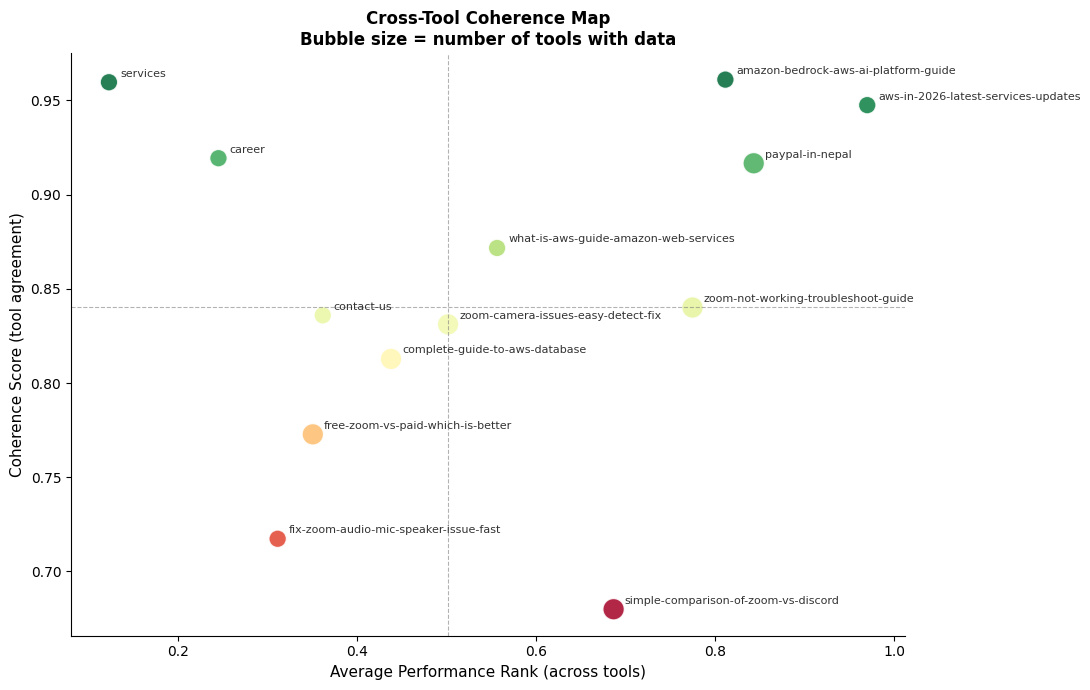

Chart saved.


In [10]:
fig, ax = plt.subplots(figsize=(11, 7))

labels = coherence_set['Page'].str.replace('/blogs/', '', regex=False).str.replace('/', '', regex=False)

scatter = ax.scatter(
    coherence_set['avg_rank'],
    coherence_set['coherence_score'],
    s=coherence_set['tool_count'] * 80,
    c=coherence_set['coherence_score'],
    cmap='RdYlGn',
    alpha=0.85,
    edgecolors='white',
    linewidth=1
)

for _, row in coherence_set.iterrows():
    label = row['Page'].replace('/blogs/', '').replace('/', '')
    ax.annotate(
        label,
        (row['avg_rank'], row['coherence_score']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8,
        color='#333333'
    )

ax.axhline(y=coherence_set['coherence_score'].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(x=coherence_set['avg_rank'].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_xlabel('Average Performance Rank (across tools)', fontsize=11)
ax.set_ylabel('Coherence Score (tool agreement)', fontsize=11)
ax.set_title(
    'Cross-Tool Coherence Map\nBubble size = number of tools with data',
    fontsize=12,
    fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-coherence/chart/coherence_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 6. Final unified opportunity score

Combining signals from all three milestones into one prioritization 
score: visibility (GSC), engagement gap (GA4), competitive opportunity 
(Ahrefs keyword potential), and coherence (tool agreement confidence).

In [11]:
final = coherence_set.merge(
    page_metrics[['Page', 'gsc_position', 'gsc_ctr']],
    on='Page', how='left'
)

def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

final['visibility_norm'] = normalize(final['gsc_impressions'])
final['engagement_gap'] = 1 - normalize(final['gsc_impressions'].rank())  # placeholder, refine below
final['confidence_weight'] = final['coherence_score']

final['unified_opportunity'] = (
    final['avg_rank'] * 0.40 +
    (1 - final['coherence_score']) * 0.30 +
    final['visibility_norm'] * 0.30
)

result = final[['Page', 'avg_rank', 'coherence_score', 'unified_opportunity']].sort_values('unified_opportunity', ascending=False)
print(result.to_string())

                                            Page  avg_rank  coherence_score  unified_opportunity
0     /blogs/aws-in-2026-latest-services-updates  0.969697         0.947514             0.703625
1                         /blogs/paypal-in-nepal  0.842876         0.916655             0.590357
2    /blogs/amazon-bedrock-aws-ai-platform-guide  0.811189         0.961065             0.519195
3     /blogs/zoom-not-working-troubleshoot-guide  0.774476         0.840088             0.454382
8    /blogs/simple-comparison-of-zoom-vs-discord  0.686298         0.679903             0.378959
4   /blogs/what-is-aws-guide-amazon-web-services  0.556090         0.871685             0.330989
7      /blogs/zoom-camera-issues-easy-detect-fix  0.501311         0.831131             0.273006
6          /blogs/complete-guide-to-aws-database  0.437609         0.812790             0.265473
5       /blogs/free-zoom-vs-paid-which-is-better  0.350197         0.772758             0.251444
10  /blogs/fix-zoom-audio-mic-

In [13]:
# Remove duplicate
final = final.drop_duplicates(subset='Page', keep='first')

# Dedupe page_metrics before mapping
page_metrics_dedup = page_metrics.drop_duplicates(subset='Page', keep='first')

final['engagement_eff'] = final['Page'].map(
    page_metrics_dedup.set_index('Page')['engagement_efficiency']
)
final['engagement_gap_real'] = 1 - normalize(final['engagement_eff'].fillna(final['engagement_eff'].median()))

final['unified_opportunity'] = (
    final['visibility_norm'] * 0.35 +
    final['engagement_gap_real'] * 0.35 +
    final['coherence_score'] * 0.30
)

result = final[['Page', 'visibility_norm', 'engagement_gap_real', 'coherence_score', 'unified_opportunity']].sort_values('unified_opportunity', ascending=False)
print(result.to_string())

                                            Page  visibility_norm  engagement_gap_real  coherence_score  unified_opportunity
0     /blogs/aws-in-2026-latest-services-updates         1.000000             1.000000         0.947514             0.984254
1                         /blogs/paypal-in-nepal         0.760679             0.977899         0.916655             0.883499
2    /blogs/amazon-bedrock-aws-ai-platform-guide         0.610129             0.999300         0.961065             0.851619
3     /blogs/zoom-not-working-troubleshoot-guide         0.322061             0.939697         0.840088             0.693642
4   /blogs/what-is-aws-guide-amazon-web-services         0.233528             0.908611         0.871685             0.661254
6          /blogs/complete-guide-to-aws-database         0.114219             0.984679         0.812790             0.628451
11                                       /career         0.002802             0.913114         0.919353             0.596377


## 7. Final unified opportunity ranking

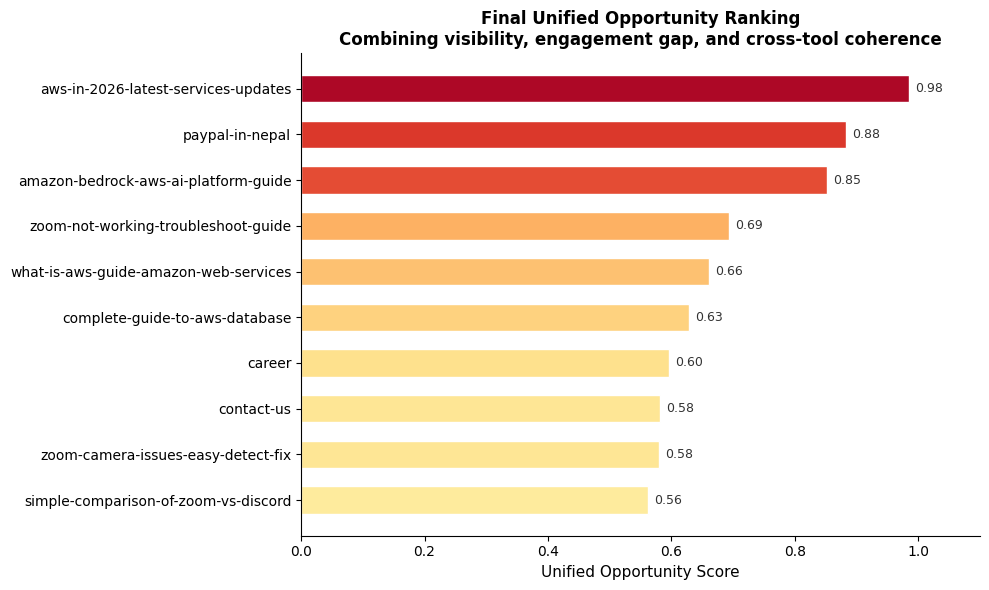

Chart saved.


In [14]:
top_final = final.sort_values('unified_opportunity', ascending=False).head(10).copy()
top_final['label'] = top_final['Page'].str.replace('/blogs/', '', regex=False).str.replace('/', '', regex=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn_r(top_final['unified_opportunity'])

bars = ax.barh(
    top_final['label'][::-1],
    top_final['unified_opportunity'][::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.6
)

for bar, score in zip(bars, top_final['unified_opportunity'][::-1]):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.2f}',
        va='center',
        fontsize=9,
        color='#333333'
    )

ax.set_xlabel('Unified Opportunity Score', fontsize=11)
ax.set_title(
    'Final Unified Opportunity Ranking\nCombining visibility, engagement gap, and cross-tool coherence',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlim(0, 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../output-coherence/chart/unified_opportunity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")